In [1]:
!pip install diagrams

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.8/27.8 MB 41.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.1/47.1 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 221.0/221.0 kB 17.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 kB 7.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.0/6.0 MB 103.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 469.0/469.0 kB 32.0 MB/s eta 0:00:00
  Attempting uninstall: graphviz
    Found existing installation: graphviz 0.21
    Uninstalling graphviz-0.21:
      Successfully uninstalled graphviz-0.21


Custom node images created in: nodes


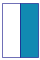

In [2]:
import matplotlib.pyplot as plt
from pathlib import Path
from IPython.display import Image

outdir = Path("nodes")
outdir.mkdir(exist_ok=True)

def make_block(label, color, linecolor, filename):
    fig, ax = plt.subplots(figsize=(0.1, 0.3))
    ax.add_patch(plt.Rectangle((0.05, 0.05), 0.9, 0.9, color=color, ec=linecolor, lw=0.2))
    #ax.text(0.5, 0.5, label, ha="center", va="center", fontsize=12, color="white", weight="bold")
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.axis("off")
    plt.tight_layout(pad=0)
    plt.savefig(outdir / filename, dpi=200, transparent=True)
    plt.close(fig)

# Create several node types
make_block("Input", "#dddddd", "black", "input.png")
make_block("Conv", "#70c1b3", "navy", "conv.png")
#make_block("UpConv", "#118ab2", "upconv.png")
#make_block("Attention", "#9b5de5", "attention.png")
#make_block("Rain Head", "#f94144", "rain_head.png")
#make_block("Lightning", "#f9c74f", "lightning_head.png")
#make_block("Discriminator", "#2a9d8f", "discriminator.png")

def make_horizontal_block(label, color, linecolor, filename):
    fig, ax = plt.subplots(figsize=(0.3, 0.1))
    ax.add_patch(plt.Rectangle((0.05, 0.05), 0.9, 0.9, color=color, ec=linecolor, lw=0.2))
    #ax.text(0.5, 0.5, label, ha="center", va="center", fontsize=12, color="white", weight="bold")
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.axis("off")
    plt.tight_layout(pad=0)
    plt.savefig(outdir / filename, dpi=200, transparent=True)
    plt.close(fig)

make_horizontal_block("Output", "#dddddd", "black", "output.png")

def make_concat_block(label, color, linecolor, filename):
    fig, ax = plt.subplots(figsize=(0.2, 0.3))
    ax.add_patch(plt.Rectangle((0.05, 0.05), 0.45, 0.9, color="white", ec=linecolor, lw=0.2))
    ax.add_patch(plt.Rectangle((0.5, 0.05), 0.45, 0.9, color=color, ec=linecolor, lw=0.2))
    #ax.text(0.5, 0.5, label, ha="center", va="center", fontsize=12, color="white", weight="bold")
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.axis("off")
    plt.tight_layout(pad=0)
    plt.savefig(outdir / filename, dpi=200, transparent=True)
    plt.close(fig)

make_concat_block("Concat", "#118ab2", "navy", "concat.png")

print("Custom node images created in:", outdir)


#Image(filename="./nodes/conv.png")
Image(filename="./nodes/concat.png")

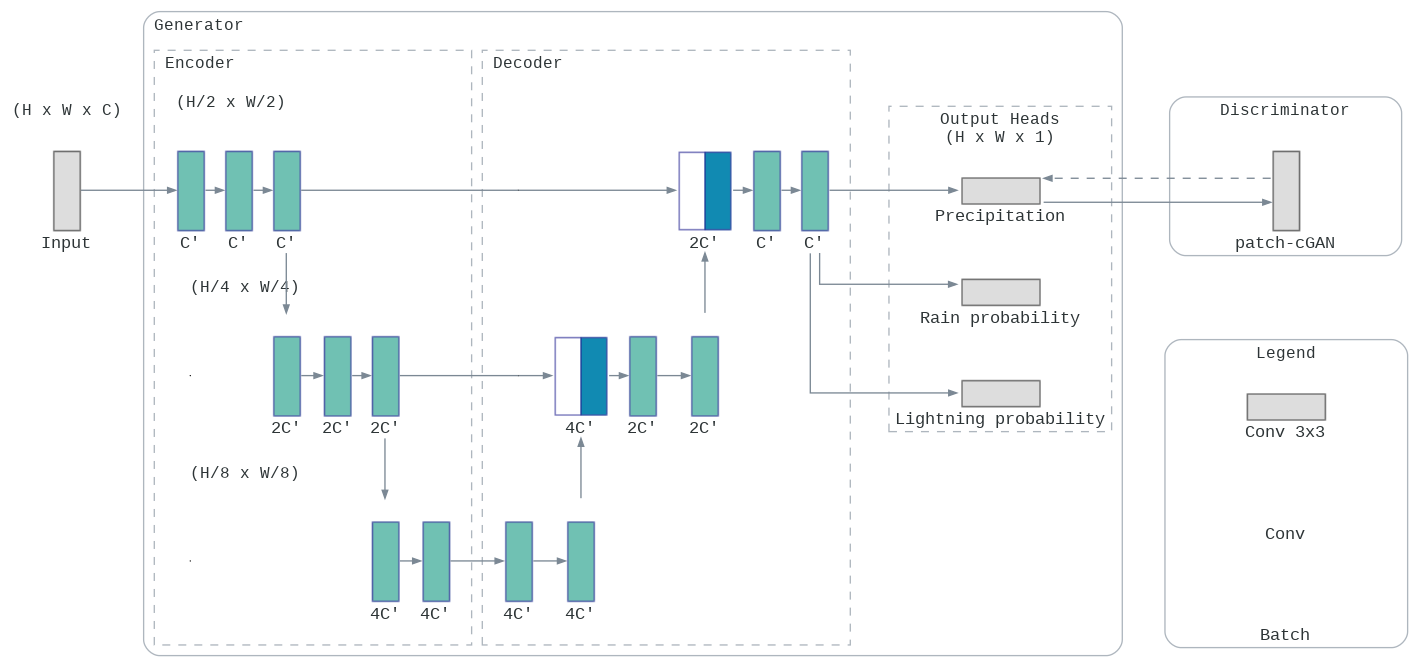

In [22]:
from IPython.display import Image
from diagrams import Diagram, Cluster, Edge
from diagrams.custom import Custom
from diagrams.generic.blank import Blank
from diagrams import Node

with Diagram(
    "",
    show=True,                # False to only save file
    direction="LR",           # left-to-right layout
    outformat="png",          # 'svg' for Figma import
    filename="diagram",
    #graph_attr={"ranksep": "0.3", "nodesep": "0.4", "pad": "0.1"},
    graph_attr={"ranksep": "0.2", "nodesep": "0.3", "pad": "0.01"},
    edge_attr={
        "arrowsize": "0.6"
    },
):

    layer_node_attrs = {
        "width": "0.3",
        "height": "1.3",
        "fixedsize": "true",
        "imagescale": "true"
    }

    concat_node_attrs = {
        "width": "0.6",
        "height": "1.3",
        "fixedsize": "true",
        "imagescale": "true"
    }

    horizontal_node_attrs = {
        "width": "0.9",
        "height": "0.75",
        "fixedsize": "true",
        "imagescale": "true"
    }

    with Cluster("(H x W x C)", direction="TB", graph_attr={"bgcolor": "transparent", "pencolor": "none", "margin": "2.0,0.0"}):
        input = Custom("  Input  ", "nodes/input.png", **layer_node_attrs)

    with Cluster("Generator", direction="LR", graph_attr={"bgcolor": "transparent"}):
        with Cluster("Encoder", direction="TB", graph_attr={"bgcolor": "transparent", "style": "dashed"}):
            with Cluster("(H/2 x W/2)", graph_attr={"pad": "0.1,0.1", "bgcolor": "transparent", "color": "none", "pencolor": "none"}):
                e1 = Custom("C'", "nodes/conv.png", **layer_node_attrs)
                e2 = Custom("C'", "nodes/conv.png", **layer_node_attrs)
                e3 = Custom("C'", "nodes/conv.png", **layer_node_attrs)

            with Cluster("(H/4 x W/4)", graph_attr={"pad": "0.1,0.1", "bgcolor": "transparent", "color": "none", "pencolor": "none"}):
                dummy1 = Node("pt", shape="point", width="0")
                e4 = Custom("2C'", "nodes/conv.png", **layer_node_attrs)
                e5 = Custom("2C'", "nodes/conv.png", **layer_node_attrs)
                e6 = Custom("2C'", "nodes/conv.png", **layer_node_attrs)

            with Cluster("(H/8 x W/8)", graph_attr={"pad": "0.1,0.1", "bgcolor": "transparent", "color": "none", "pencolor": "none"}):
                dummy2 = Node("pt", shape="point", width="0")
                e7 = Custom("4C'", "nodes/conv.png", **layer_node_attrs)
                e8 = Custom("4C'", "nodes/conv.png", **layer_node_attrs)
                #e9 = Custom("e9", "nodes/conv.png", **layer_node_attrs)

        input >> Edge() >> e1 >> Edge(minlen="1") >> e2 >> e3
        dummy1 >> Edge(minlen="2", style="invis") >> e4
        e3 >> Edge(constraint="false") >> e4
        e4 >> e5 >> e6
        dummy2 >> Edge(minlen="4", style="invis") >> e7
        e6 >> Edge(constraint="false") >> e7
        e7 >> e8

        with Cluster("Decoder", direction="TB", graph_attr={"bgcolor": "transparent", "style": "dashed"}):
            with Cluster("4", graph_attr={"pad": "0.1,0.1", "bgcolor": "transparent", "color": "none", "pencolor": "none", "style": "invis"}):
                dummy3 = Node("pt", shape="point", width="0")
                d1 = Custom("2C'", "nodes/concat.png", **concat_node_attrs)
                d2 = Custom("C'", "nodes/conv.png", **layer_node_attrs)
                d3 = Custom("C'", "nodes/conv.png", **layer_node_attrs)

            with Cluster("5", graph_attr={"pad": "0.1,0.1", "bgcolor": "transparent", "color": "none", "pencolor": "none", "style": "invis"}):
                dummy4 = Node("pt", shape="point", width="0")
                d4 = Custom("4C'", "nodes/concat.png", **concat_node_attrs)
                d5 = Custom("2C'", "nodes/conv.png", **layer_node_attrs)
                d6 = Custom("2C'", "nodes/conv.png", **layer_node_attrs)

            with Cluster("6", graph_attr={"pad": "0.1,0.1", "bgcolor": "transparent", "color": "none", "pencolor": "none", "style": "invis"}):
                d7 = Custom("4C'", "nodes/conv.png", **layer_node_attrs)
                d8 = Custom("4C'", "nodes/conv.png", **layer_node_attrs)

        d7 >> d8
        d8 >> Edge(constraint="false") >> d4
        dummy4 >> Edge(minlen="1.5") >> d4
        d4 >> d5 >> d6
        d6 >> Edge(constraint="false") >> d1
        dummy3 >> Edge(minlen="3.5") >> d1
        d1 >> d2 >> d3

        e8 >> d7
        e6 - Edge(constraint="LR") - dummy4
        e3 - Edge(constraint="LR") - dummy3

        with Cluster("    Output Heads    \n    (H x W x 1)    ", direction="TB", graph_attr={"bgcolor": "transparent", "style": "dashed", "margin": "2.0,0.5"}):
            o1 = Custom("Rain probability", "nodes/output.png", **horizontal_node_attrs)
            o2 = Custom("Precipitation", "nodes/output.png", **horizontal_node_attrs)
            o3 = Custom("Lightning probability", "nodes/output.png", **horizontal_node_attrs)

        d3 >> Edge(minlen="2") >> o2
        d3 >> Edge(constraint="LR") >> o1
        d3 >> Edge(constraint="LR") >> o3

    with Cluster("Extra", direction="TB", graph_attr={"bgcolor": "transparent", "style": "invis"}):
        with Cluster("    Discriminator    ", graph_attr={"bgcolor": "transparent", "margin": "2.0,0.5"}):
            gan = Custom("patch-cGAN", "nodes/input.png", **layer_node_attrs)

        o2 >> Edge(minlen="2") >> gan
        gan >> Edge(constraint="LR", style="dashed") >> o2

        # --- legend ---
        with Cluster("        Legend        ", direction="TB", graph_attr={
            "bgcolor": "transparent",
            "margin": "2.0,0.5"
        }):
            l1 = Custom("Conv 3x3", "nodes/output.png", **horizontal_node_attrs)
            Blank("Conv", **horizontal_node_attrs)
            Blank("Batch", **horizontal_node_attrs)

        gan >> Edge(constraint="false", minlen="4", style="invis") >> l1

# Display the image inline
Image(filename="diagram.png")